# Prodigy InfoTech Internship Task 5

In [ ]:
# importing libraries
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

In [58]:
# loading the accident dataset
acc_data=pd.read_csv(r"C:\Users\LENOVO\Downloads\Accident Dataset\cleaned.csv")
acc_data.head()

,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Lanes_or_Medians,Types_of_Junction,Road_surface_type,Light_conditions,Weather_conditions,Type_of_collision,Vehicle_movement,Pedestrian_movement,Cause_of_accident,Accident_severity
0,18-30,Male,Above high school,Employee,1-2yr,Unknown,No junction,Asphalt roads,Daylight,Normal,Collision with roadside-parked vehicles,Going straight,Not a Pedestrian,Moving Backward,2
1,31-50,Male,Junior high school,Employee,Above 10yr,Undivided Two way,No junction,Asphalt roads,Daylight,Normal,Vehicle with vehicle collision,Going straight,Not a Pedestrian,Overtaking,2
2,18-30,Male,Junior high school,Employee,1-2yr,other,No junction,Asphalt roads,Daylight,Normal,Collision with roadside objects,Going straight,Not a Pedestrian,Changing lane to the left,1
3,18-30,Male,Junior high school,Employee,5-10yr,other,Y Shape,Earth roads,Darkness - lights lit,Normal,Vehicle with vehicle collision,Going straight,Not a Pedestrian,Changing lane to the right,2
4,18-30,Male,Junior high school,Employee,2-5yr,other,Y Shape,Asphalt roads,Darkness - lights lit,Normal,Vehicle with vehicle collision,Going straight,Not a Pedestrian,Overtaking,2


In [59]:
# dataset column names
acc_data.columns

Index(['Age_band_of_driver', 'Sex_of_driver', 'Educational_level',
       'Vehicle_driver_relation', 'Driving_experience', 'Lanes_or_Medians',
       'Types_of_Junction', 'Road_surface_type', 'Light_conditions',
       'Weather_conditions', 'Type_of_collision', 'Vehicle_movement',
       'Pedestrian_movement', 'Cause_of_accident', 'Accident_severity'],
      dtype='object')

In [60]:
# number of rows and columns in the dataset
acc_data.shape

(12316, 15)

In [61]:
# statistical analysis of the data
# acc_data.describe()

,Accident_severity
count,12316.000000
mean,1.832819
std,0.406082
min,0.000000
25%,2.000000
50%,2.000000
75%,2.000000
max,2.000000


In [62]:
# checking for null values in the dataset
acc_data.isnull().sum()

Age_band_of_driver         0
Sex_of_driver              0
Educational_level          0
Vehicle_driver_relation    0
Driving_experience         0
Lanes_or_Medians           0
Types_of_Junction          0
Road_surface_type          0
Light_conditions           0
Weather_conditions         0
Type_of_collision          0
Vehicle_movement           0
Pedestrian_movement        0
Cause_of_accident          0
Accident_severity          0
dtype: int64

In [63]:
# loading the original rta dataset as well
acc_rta=pd.read_csv(r"C:\Users\LENOVO\Downloads\Accident Dataset\RTA Dataset.csv")
print(acc_rta.columns.tolist())

['Time', 'Day_of_week', 'Age_band_of_driver', 'Sex_of_driver', 'Educational_level', 'Vehicle_driver_relation', 'Driving_experience', 'Type_of_vehicle', 'Owner_of_vehicle', 'Service_year_of_vehicle', 'Defect_of_vehicle', 'Area_accident_occured', 'Lanes_or_Medians', 'Road_allignment', 'Types_of_Junction', 'Road_surface_type', 'Road_surface_conditions', 'Light_conditions', 'Weather_conditions', 'Type_of_collision', 'Number_of_vehicles_involved', 'Number_of_casualties', 'Vehicle_movement', 'Casualty_class', 'Sex_of_casualty', 'Age_band_of_casualty', 'Casualty_severity', 'Work_of_casuality', 'Fitness_of_casuality', 'Pedestrian_movement', 'Cause_of_accident', 'Accident_severity']


In [64]:
# merging important columns from rta dataset to cleaned dataset
cols_to_merge=acc_rta[['Time','Day_of_week','Area_accident_occured','Road_surface_conditions']]
cleaned_merged=pd.concat([acc_data,cols_to_merge],axis=1)
cleaned_merged.to_csv("cleaned_with_time_day.csv",index=False)

In [65]:
cleaned_data=pd.read_csv("cleaned_with_time_day.csv")
print(cleaned_data.head(10))

  Age_band_of_driver Sex_of_driver   Educational_level  \
0              18-30          Male   Above high school   
1              31-50          Male  Junior high school   
2              18-30          Male  Junior high school   
3              18-30          Male  Junior high school   
4              18-30          Male  Junior high school   
5              31-50          Male             Unknown   
6              18-30          Male  Junior high school   
7              18-30          Male  Junior high school   
8              18-30          Male  Junior high school   
9              18-30          Male  Junior high school   

  Vehicle_driver_relation Driving_experience   Lanes_or_Medians  \
0                Employee              1-2yr            Unknown   
1                Employee         Above 10yr  Undivided Two way   
2                Employee              1-2yr              other   
3                Employee             5-10yr              other   
4                Employee 

In [66]:
# checking the columns in cleaned dataset after merging
cleaned_data.columns

Index(['Age_band_of_driver', 'Sex_of_driver', 'Educational_level',
       'Vehicle_driver_relation', 'Driving_experience', 'Lanes_or_Medians',
       'Types_of_Junction', 'Road_surface_type', 'Light_conditions',
       'Weather_conditions', 'Type_of_collision', 'Vehicle_movement',
       'Pedestrian_movement', 'Cause_of_accident', 'Accident_severity', 'Time',
       'Day_of_week', 'Area_accident_occured', 'Road_surface_conditions'],
      dtype='object')

In [67]:
# extracting hour from time
cleaned_data['Hour']=pd.to_datetime(cleaned_data['Time'],errors='coerce').dt.hour
print(cleaned_data[['Time','Hour']].head())

       Time  Hour
0  17:02:00    17
1  17:02:00    17
2  17:02:00    17
3   1:06:00     1
4   1:06:00     1


In [68]:
import matplotlib.pyplot as plt
import seaborn as sns

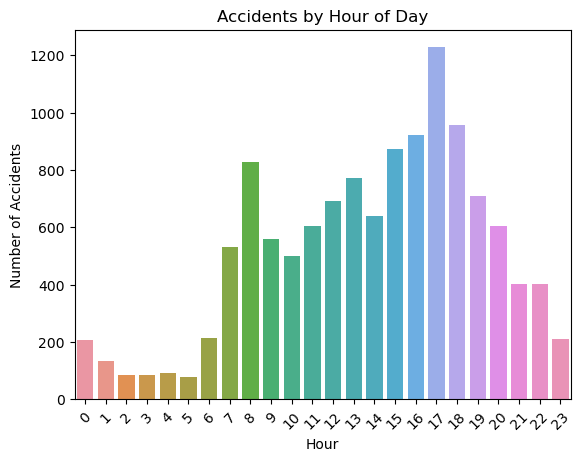

In [69]:
# number of accidents by hour of data countplot
sns.countplot(x='Hour',data=cleaned_data)
plt.title("Accidents by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=45)
plt.show()

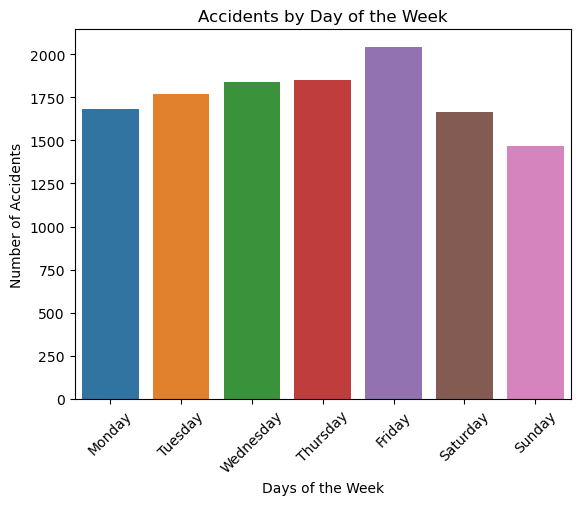

In [70]:
# number of accidents by days of week countplot
sns.countplot(x='Day_of_week',data=cleaned_data,order=[
    'Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])
plt.title("Accidents by Day of the Week")
plt.xlabel("Days of the Week")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=45)
plt.show()

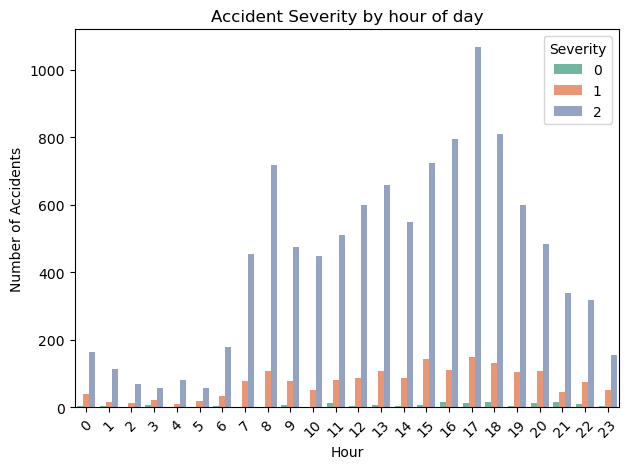

In [71]:
# Accident Severity by hour of day countplot
sns.countplot(data=cleaned_data,x='Hour',hue='Accident_severity',palette='Set2')
plt.title("Accident Severity by hour of day")
plt.xlabel("Hour")
plt.ylabel("Number of Accidents")
plt.legend(title='Severity')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

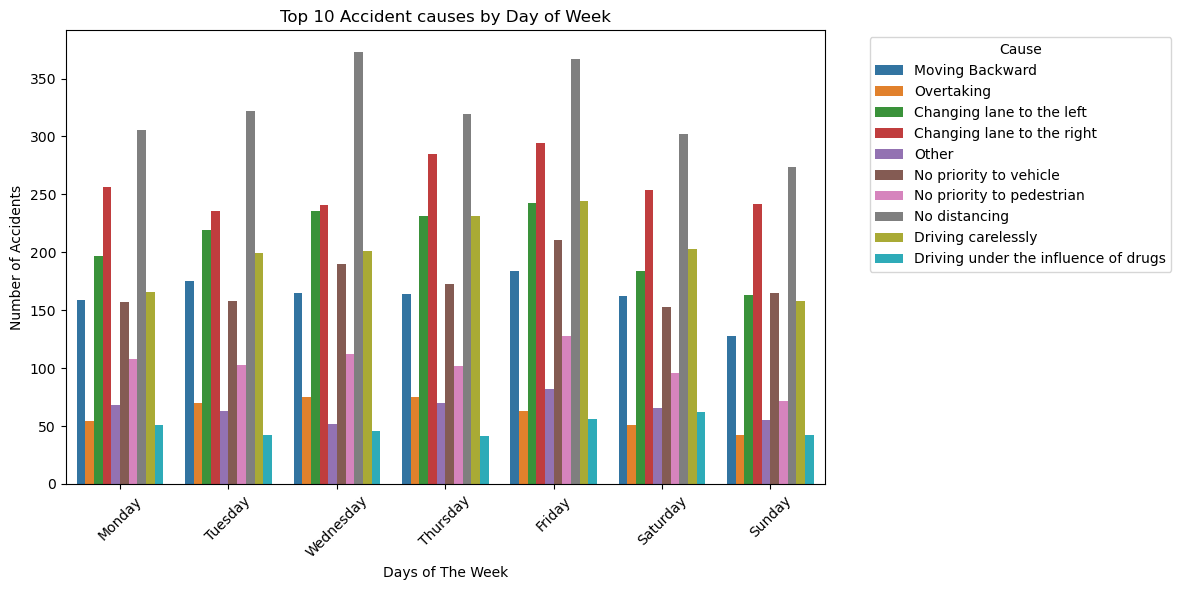

In [72]:
# Top 10 Accident causes by Day of Week and the causes
top_causes=cleaned_data['Cause_of_accident'].value_counts().head(10).index
filtered=cleaned_data[cleaned_data['Cause_of_accident'].isin(top_causes)]
order_days=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
plt.figure(figsize=(12,6))
sns.countplot(data=filtered,x='Day_of_week',hue='Cause_of_accident',order=order_days)
plt.title("Top 10 Accident causes by Day of Week")
plt.xlabel("Days of The Week")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=45)
plt.legend(title='Cause',bbox_to_anchor=(1.05,1),loc='upper left')
plt.tight_layout()
plt.show()

In [73]:
cleaned_data=cleaned_data.dropna(subset=['Area_accident_occured'])

In [74]:
cleaned_data['Area_accident_occured'].isnull().sum()

0

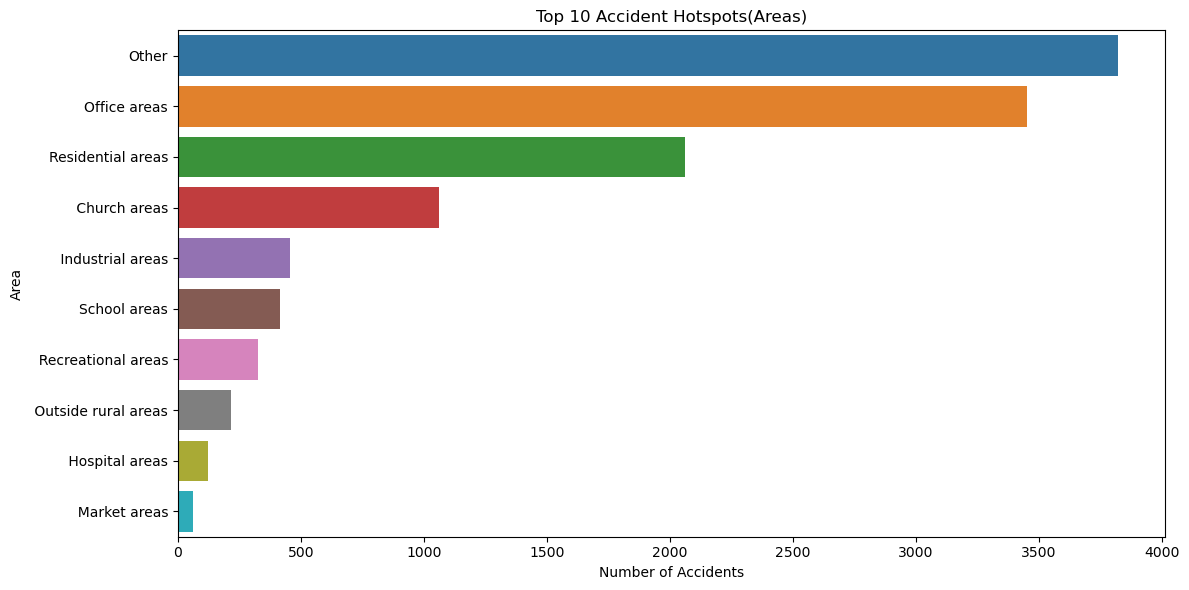

In [75]:
# Top 10 Accident Hotspots(Areas)
plt.figure(figsize=(12,6))
sns.countplot(y='Area_accident_occured',data=cleaned_data,
              order=cleaned_data['Area_accident_occured'].value_counts().head(10).index)
plt.title("Top 10 Accident Hotspots(Areas)")
plt.xlabel("Number of Accidents")
plt.ylabel("Area")
plt.tight_layout()
plt.show()

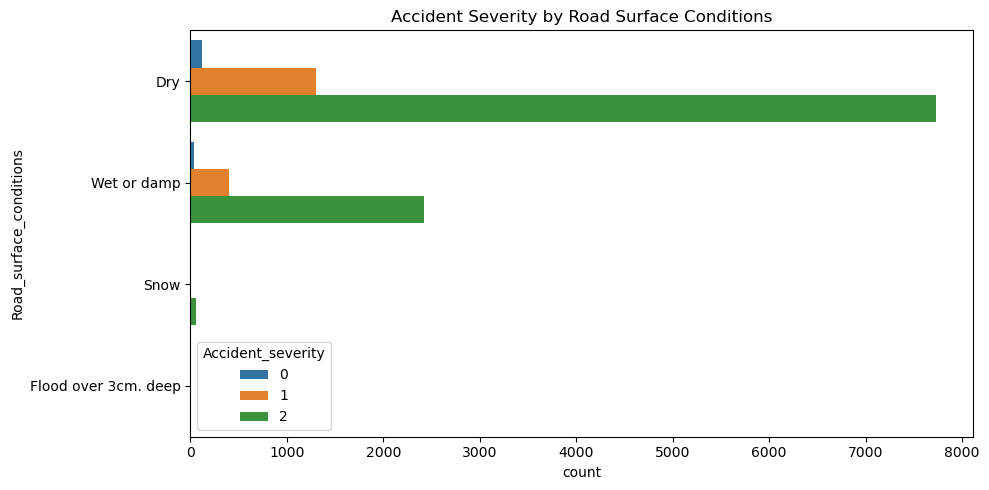

In [76]:
# Accident Severity by Road Surface Conditions
plt.figure(figsize=(10,5))
sns.countplot(y='Road_surface_conditions',hue='Accident_severity',data=cleaned_data,
              order=cleaned_data['Road_surface_conditions'].value_counts().index)
plt.title("Accident Severity by Road Surface Conditions")
plt.tight_layout()
plt.show()

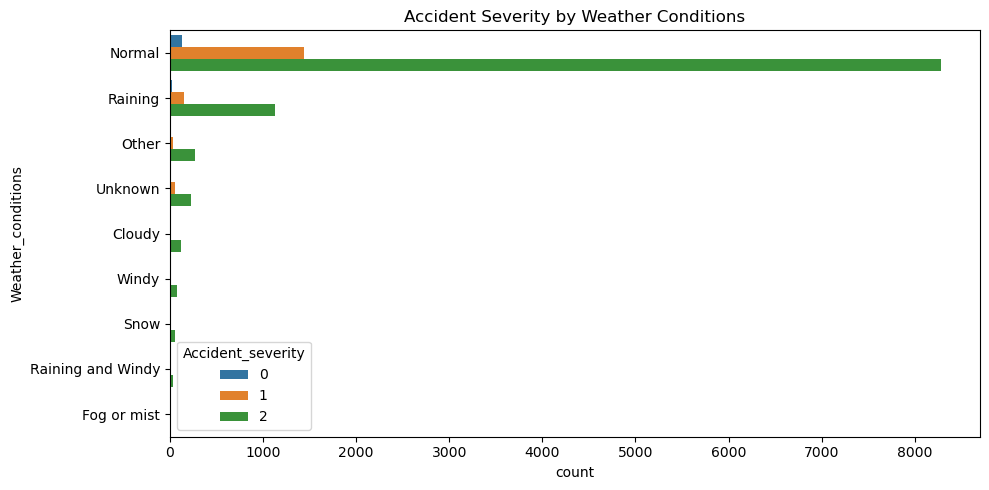

In [77]:
# Accident Severity by Weather Conditions
plt.figure(figsize=(10,5))
sns.countplot(y='Weather_conditions',hue='Accident_severity',data=cleaned_data,
              order=cleaned_data['Weather_conditions'].value_counts().index)
plt.title("Accident Severity by Weather Conditions")
plt.tight_layout()
plt.show()

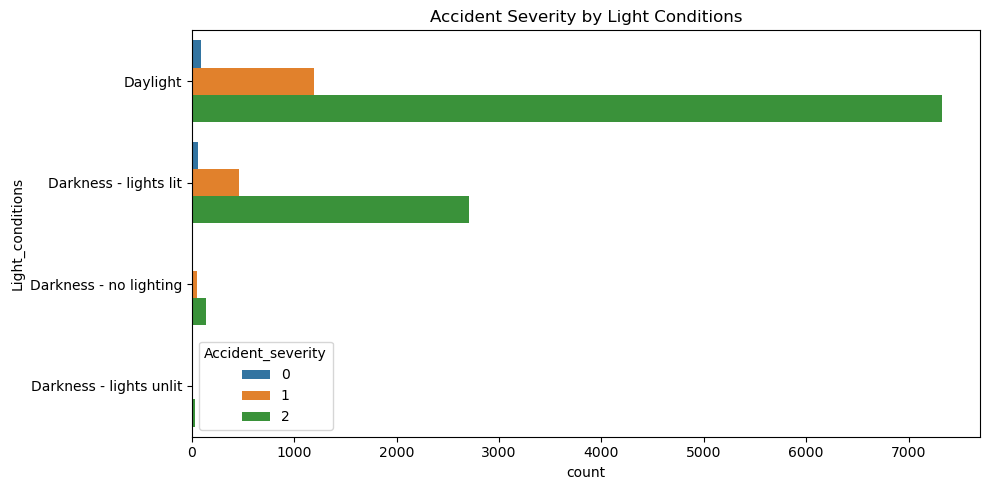

In [78]:
# Accident Severity by Light Conditions
plt.figure(figsize=(10,5))
sns.countplot(y='Light_conditions',hue='Accident_severity',data=cleaned_data,
              order=cleaned_data['Light_conditions'].value_counts().index)
plt.title("Accident Severity by Light Conditions")
plt.tight_layout()
plt.show()

In [79]:
cleaned_data['Area_accident_occured'].isnull().sum()

0

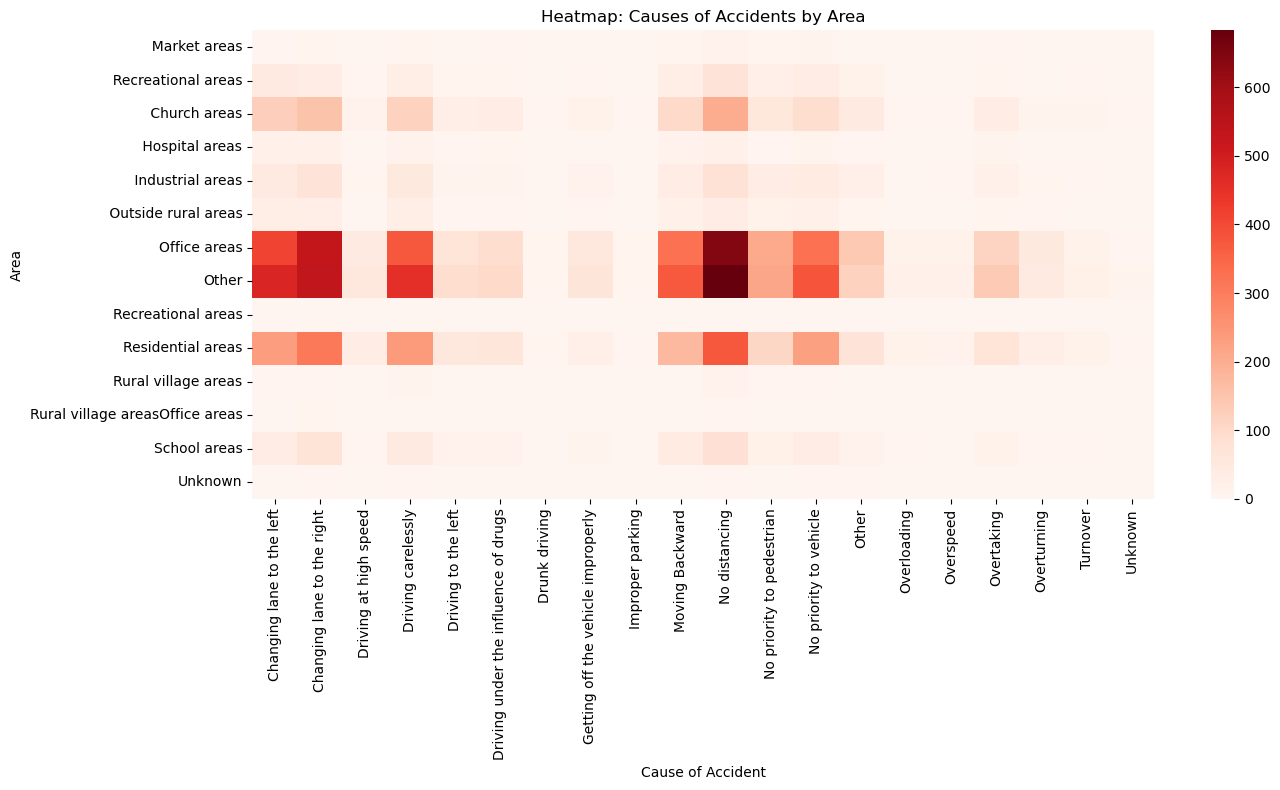

In [80]:
# Heatmap: Causes of Accidents by Area
heatmap_data=pd.crosstab(cleaned_data['Area_accident_occured'],cleaned_data['Cause_of_accident'])
plt.figure(figsize=(14,8))
sns.heatmap(heatmap_data,cmap='Reds')
plt.title("Heatmap: Causes of Accidents by Area")
plt.xlabel("Cause of Accident")
plt.ylabel("Area")
plt.tight_layout()
plt.show()